# Regression Analysis on the Diabetes Dataset

This notebook presents a regression modeling workflow using the Diabetes dataset from scikit-learn. The analysis includes data preparation, model training, performance comparison, ensemble methods, and visualization of results.

In [17]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load diabetes dataset as a pandas DataFrame
diabetes = load_diabetes(as_frame=True)
X = diabetes.data        # features
y = diabetes.target      # target

# Combine into one DataFrame
df = X.copy()
df["target"] = y

# Save to CSV for submission
df.to_csv("diabetes_regression.csv", index=False)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [18]:
# Features and target
X = df.drop(columns=["target"])
y = df["target"]

In this section, I examine the target distribution and feature correlations to understand the regression problem before modeling. The target appears roughly continuous, and several predictors show moderate correlation with the target, which suggests that both linear and nonlinear models may perform reasonably well on this dataset.

## Data Exploration

The following visualizations summarize the distribution of the target variable and the relationships between features and the target before model evaluation.

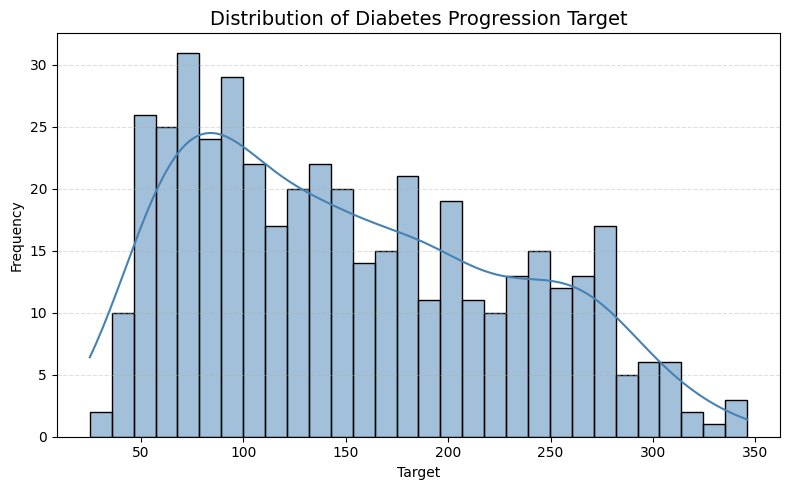

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["target"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Diabetes Progression Target", fontsize=14)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

This histogram shows how the target variable is distributed across the dataset. Understanding the shape of the target helps interpret whether the regression problem appears balanced or skewed.

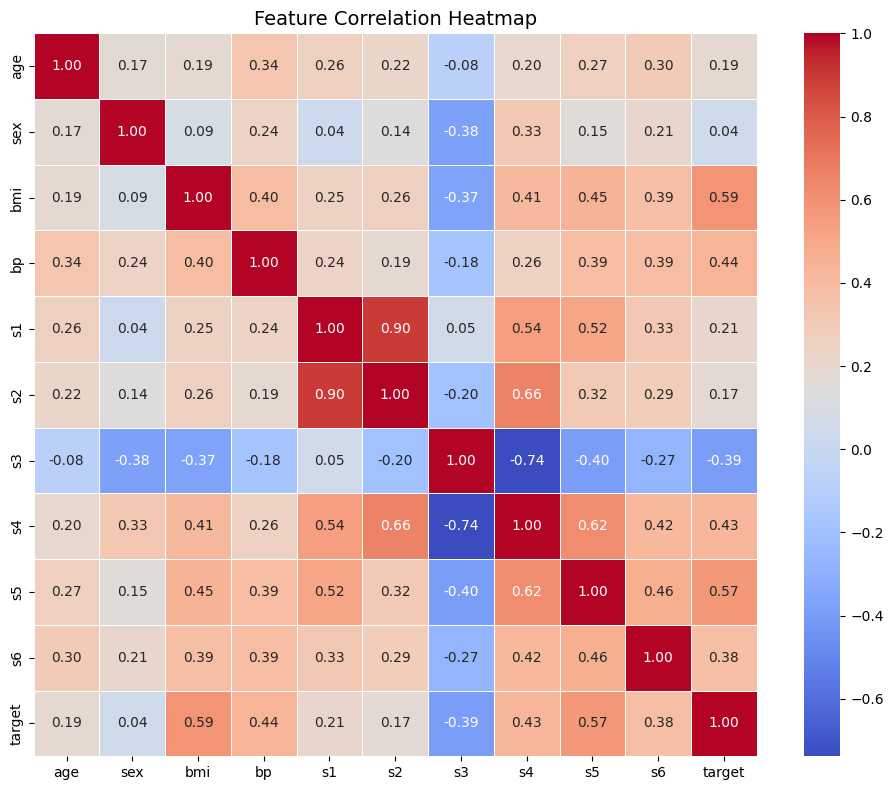

In [20]:
plt.figure(figsize=(10, 8))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

This heatmap highlights the relationships among the predictor variables and the target. It helps identify which features are more strongly associated with the target and whether strong inter-feature correlations are present.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

In [22]:
!pip install xgboost

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

for name, model in models.items():
    # Validation
    y_val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    # Test
    y_test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Val_MAE": val_mae,
        "Val_MSE": val_mse,
        "Val_R2": val_r2,
        "Test_MAE": test_mae,
        "Test_MSE": test_mse,
        "Test_R2": test_r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,Val_MAE,Val_MSE,Val_R2,Test_MAE,Test_MSE,Test_R2
0,LinearRegression,38.216681,2499.321235,0.511262,45.566811,3139.368343,0.447098
1,DecisionTree,61.560606,6207.924242,-0.213949,58.492537,5195.268657,0.085014
2,RandomForest,39.250833,2704.611068,0.471118,45.223358,2904.349677,0.488489
3,GradientBoosting,42.346712,2858.226203,0.441079,47.070396,3281.488415,0.422067
4,KNN,41.457576,2969.180000,0.419382,46.510448,3471.280597,0.388641
5,XGBoost,41.842360,3018.397495,0.409757,45.401286,3318.623303,0.415527


In [35]:
base_model_names = [
    "LinearRegression",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting",
    "KNN",
    "XGBoost"
]

top3 = (
    results_df[results_df["Model"].isin(base_model_names)]
    .sort_values("Val_MSE")
    .head(3)["Model"]
    .tolist()
)

top3

['LinearRegression', 'RandomForest', 'GradientBoosting']

The models in this table were all trained on the training set and evaluated on the validation and test sets using MAE, MSE, and R². These metrics quantify prediction error (MAE and MSE) and goodness-of-fit (R²), and they provide a basis for comparing models and selecting candidates for ensembling.

In [38]:
from sklearn.ensemble import VotingRegressor

top3_estimators = [(name, models[name]) for name in top3]

voting_reg = VotingRegressor(estimators=top3_estimators)
voting_reg.fit(X_train, y_train)

y_val_pred_voting = voting_reg.predict(X_val)
y_test_pred_voting = voting_reg.predict(X_test)

ensemble_row = {
    "Model": "Voting_Top3",
    "Val_MAE": mean_absolute_error(y_val, y_val_pred_voting),
    "Val_MSE": mean_squared_error(y_val, y_val_pred_voting),
    "Val_R2": r2_score(y_val, y_val_pred_voting),
    "Test_MAE": mean_absolute_error(y_test, y_test_pred_voting),
    "Test_MSE": mean_squared_error(y_test, y_test_pred_voting),
    "Test_R2": r2_score(y_test, y_test_pred_voting)
}

results_df = results_df[~results_df["Model"].isin(["Voting_Top3", "Bayesian_Ensemble"])]
results_df = pd.concat([results_df, pd.DataFrame([ensemble_row])], ignore_index=True)
results_df

,Model,Val_MAE,Val_MSE,Val_R2,Test_MAE,Test_MSE,Test_R2
0,LinearRegression,38.216681,2499.321235,0.511262,45.566811,3139.368343,0.447098
1,DecisionTree,61.560606,6207.924242,-0.213949,58.492537,5195.268657,0.085014
2,RandomForest,39.250833,2704.611068,0.471118,45.223358,2904.349677,0.488489
3,GradientBoosting,42.346712,2858.226203,0.441079,47.070396,3281.488415,0.422067
4,KNN,41.457576,2969.180000,0.419382,46.510448,3471.280597,0.388641
5,XGBoost,41.842360,3018.397495,0.409757,45.401286,3318.623303,0.415527
6,Voting_Top3,38.816186,2532.139425,0.504844,45.064323,2953.743658,0.479790


In [37]:
from sklearn.linear_model import BayesianRidge

top3_models = [models[name] for name in top3]

train_meta = np.column_stack([m.predict(X_train) for m in top3_models])
val_meta = np.column_stack([m.predict(X_val) for m in top3_models])
test_meta = np.column_stack([m.predict(X_test) for m in top3_models])

bayes_meta = BayesianRidge()
bayes_meta.fit(train_meta, y_train)

y_val_pred_bayes = bayes_meta.predict(val_meta)
y_test_pred_bayes = bayes_meta.predict(test_meta)

bayes_row = {
    "Model": "Bayesian_Ensemble",
    "Val_MAE": mean_absolute_error(y_val, y_val_pred_bayes),
    "Val_MSE": mean_squared_error(y_val, y_val_pred_bayes),
    "Val_R2": r2_score(y_val, y_val_pred_bayes),
    "Test_MAE": mean_absolute_error(y_test, y_test_pred_bayes),
    "Test_MSE": mean_squared_error(y_test, y_test_pred_bayes),
    "Test_R2": r2_score(y_test, y_test_pred_bayes)
}

results_df = results_df[results_df["Model"] != "Bayesian_Ensemble"]
results_df = pd.concat([results_df, pd.DataFrame([bayes_row])], ignore_index=True)
results_df

,Model,Val_MAE,Val_MSE,Val_R2,Test_MAE,Test_MSE,Test_R2
0,LinearRegression,38.216681,2499.321235,0.511262,45.566811,3139.368343,0.447098
1,DecisionTree,61.560606,6207.924242,-0.213949,58.492537,5195.268657,0.085014
2,RandomForest,39.250833,2704.611068,0.471118,45.223358,2904.349677,0.488489
3,GradientBoosting,42.346712,2858.226203,0.441079,47.070396,3281.488415,0.422067
4,KNN,41.457576,2969.180000,0.419382,46.510448,3471.280597,0.388641
5,XGBoost,41.842360,3018.397495,0.409757,45.401286,3318.623303,0.415527
6,Voting_Top3,38.816186,2532.139425,0.504844,45.064323,2953.743658,0.479790
7,Voting_Top3,38.816186,2532.139425,0.504844,45.064323,2953.743658,0.479790
8,Bayesian_Ensemble,42.464541,3169.634089,0.380183,45.541522,3069.841619,0.459343


## Model Comparison Visuals

The next charts compare model performance across the validation and test datasets using the required regression metrics.

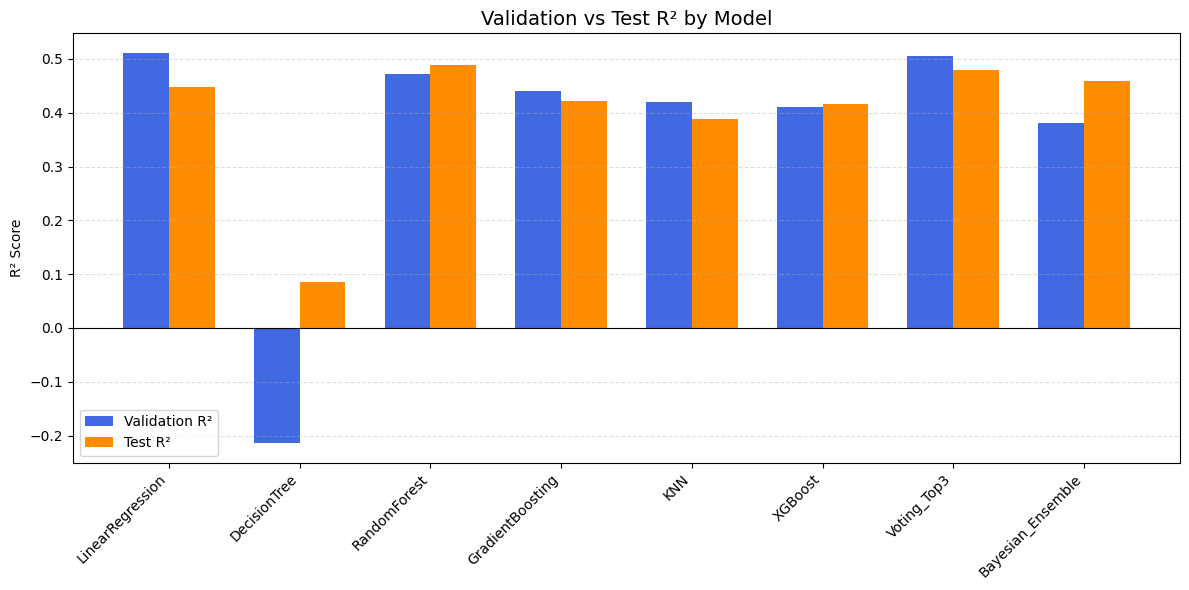

In [28]:
import numpy as np

plot_df = results_df.copy()

x = np.arange(len(plot_df["Model"]))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["Val_R2"], width, label="Validation R²", color="royalblue")
plt.bar(x + width/2, plot_df["Test_R2"], width, label="Test R²", color="darkorange")

plt.xticks(x, plot_df["Model"], rotation=45, ha="right")
plt.ylabel("R² Score")
plt.title("Validation vs Test R² by Model", fontsize=14)
plt.axhline(0, color="black", linewidth=0.8)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

This grouped bar chart compares model goodness-of-fit across the validation and test sets. Higher R² values indicate stronger explanatory power and better predictive performance.

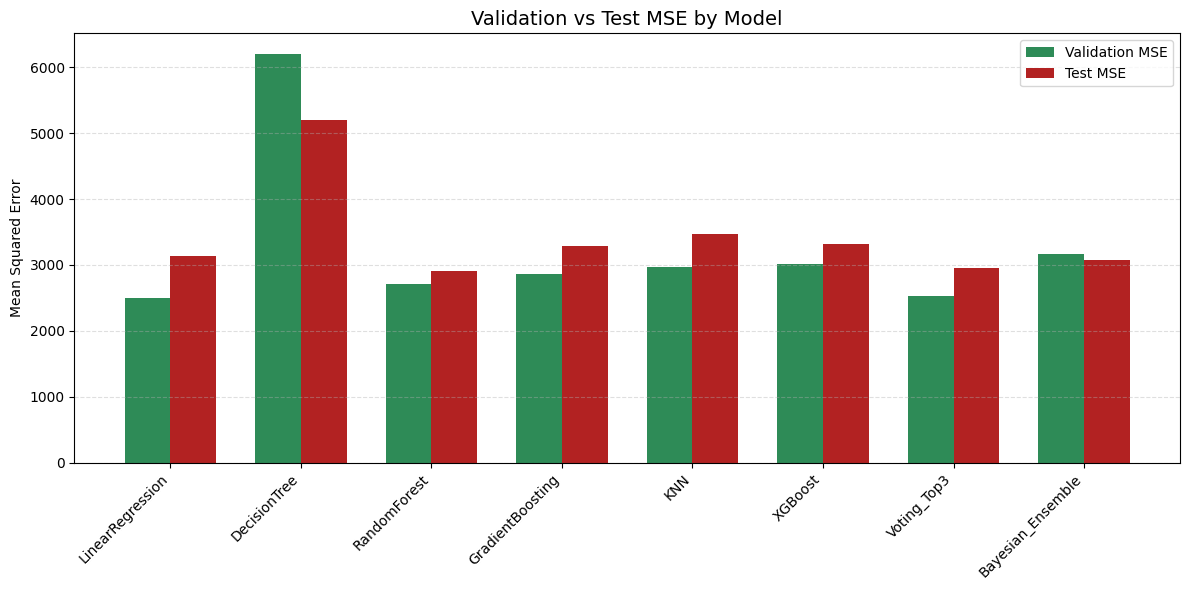

In [29]:
x = np.arange(len(plot_df["Model"]))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["Val_MSE"], width, label="Validation MSE", color="seagreen")
plt.bar(x + width/2, plot_df["Test_MSE"], width, label="Test MSE", color="firebrick")

plt.xticks(x, plot_df["Model"], rotation=45, ha="right")
plt.ylabel("Mean Squared Error")
plt.title("Validation vs Test MSE by Model", fontsize=14)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

This chart compares model error across the validation and test sets. Lower MSE values indicate more accurate predictions and help reveal whether a model generalizes well.

The bar charts summarize performance across models on both validation and test data. They make it easier to see that Linear Regression performs best on validation, while Random Forest and the Voting ensemble achieve slightly stronger generalization on the test set.

## Best Model Diagnostics

The following plot evaluates how closely the predictions from the best-performing model align with the actual target values.

This scatter plot compares actual target values with predicted values from the Random Forest model. Points closer to the diagonal reference line indicate more accurate predictions.

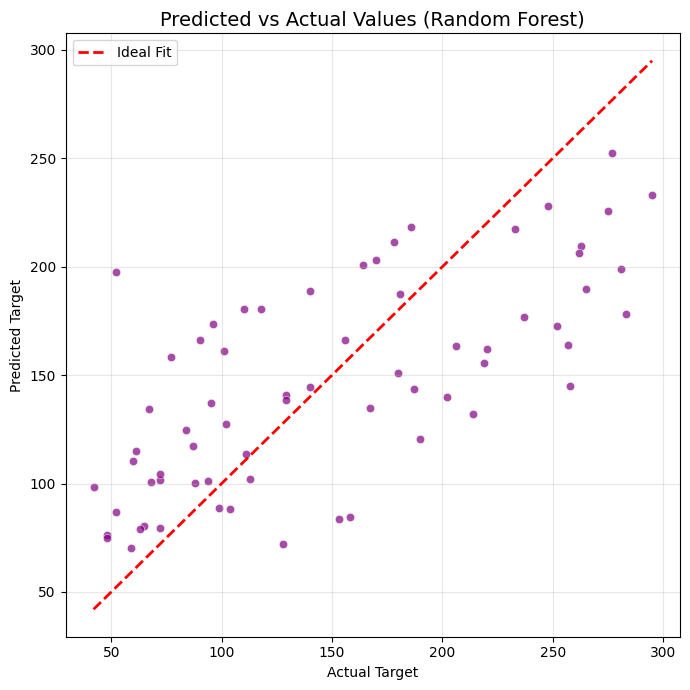

In [30]:
best_model = models["RandomForest"]
y_test_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_test_pred_best, color="purple", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Predicted vs Actual Values (Random Forest)", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The Random Forest model was selected for diagnostic plots because it achieved the highest R² on the test set among individual or ensemble models. The predicted-versus-actual plot shows points clustering around the diagonal, indicating reasonable predictive accuracy, with some dispersion that reflects remaining unexplained variance.

In [31]:
# Save the final results table including ensemble models
results_df.to_csv("model_results_val_test_final.csv", index=False)

# Display final table
results_df

,Model,Val_MAE,Val_MSE,Val_R2,Test_MAE,Test_MSE,Test_R2
0,LinearRegression,38.216681,2499.321235,0.511262,45.566811,3139.368343,0.447098
1,DecisionTree,61.560606,6207.924242,-0.213949,58.492537,5195.268657,0.085014
2,RandomForest,39.250833,2704.611068,0.471118,45.223358,2904.349677,0.488489
3,GradientBoosting,42.346712,2858.226203,0.441079,47.070396,3281.488415,0.422067
4,KNN,41.457576,2969.180000,0.419382,46.510448,3471.280597,0.388641
5,XGBoost,41.842360,3018.397495,0.409757,45.401286,3318.623303,0.415527
6,Voting_Top3,38.816186,2532.139425,0.504844,45.064323,2953.743658,0.479790
7,Bayesian_Ensemble,42.464541,3169.634089,0.380183,45.541522,3069.841619,0.459343


## Discussion

Overall, Linear Regression achieved the best validation performance, suggesting that a linear relationship explains a substantial portion of the variance in the target. However, on the held-out test set, Random Forest slightly outperformed Linear Regression in terms of R² and MSE, indicating better generalization, likely because it can model nonlinear interactions between features. The Voting ensemble performed comparably to the best individual models, while the Bayesian ensemble did not provide additional gains in this setting, suggesting that a simple averaging-based ensemble was sufficient for this dataset.